<a href="https://colab.research.google.com/github/ibel123/OIBSIP/blob/main/DataScience-Task4-EmailSpamDetection/Email_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Email Spam Detection with Machine Learning

Oasis Infobyte SIP, Data Science Track, Task 4

This notebook builds a binary classifier that reads a text message and predicts whether it is spam or a legitimate message, usually called ham. This is a Natural Language Processing (NLP) task, meaning the input is raw text rather than numbers.

We will follow these steps:
1. Load the dataset
2. Check the class balance (how many spam vs ham messages)
3. Clean and preprocess the text
4. Turn text into numbers using TF-IDF
5. Split the data into training and testing sets
6. Train two classifiers
7. Evaluate both models
8. Discuss why recall matters more than accuracy for spam detection
9. Bonus: visualize the most common words in spam vs ham using word clouds


## Step 1: Import the libraries we need

We also need to download two small NLTK resources the first time we run this: a list of common English stopwords, and a tool that helps split sentences into individual words.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set(style="whitegrid")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Step 2: Load the dataset

You need to download the SMS Spam Collection dataset from Kaggle first. Search for "SMS Spam Collection dataset" on kaggle.com and download the CSV file, often named `spam.csv`.

Run the cell below and upload your CSV file when the upload button appears.

In [2]:
from google.colab import files

uploaded = files.upload()


Saving spam.csv to spam.csv


In [3]:
filename = list(uploaded.keys())[0]

# This dataset is saved with a different text encoding, latin-1 avoids errors when reading it
df = pd.read_csv(filename, encoding="latin-1")

print("Column names in this dataset:")
print(list(df.columns))

df.head()


Column names in this dataset:
['Category', 'Message']


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 2b: Clean up the columns

The standard version of this dataset has extra unnamed empty columns, and its two useful columns are usually called `v1` (the label) and `v2` (the message text). We rename these to clearer names and drop anything we do not need.

## Step 3: Check the class distribution

Before doing anything else, we check how many spam messages and how many ham messages we have. This matters a lot in spam detection, because these datasets are usually imbalanced, meaning there are far more ham messages than spam ones. This imbalance affects how we should judge the model later.

In [4]:
print("Message counts by label:")
print(df["Category"].value_counts())
print()
print("Message percentages by label:")
print(df["Category"].value_counts(normalize=True) * 100)


Message counts by label:
Category
ham     4825
spam     747
Name: count, dtype: int64

Message percentages by label:
Category
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


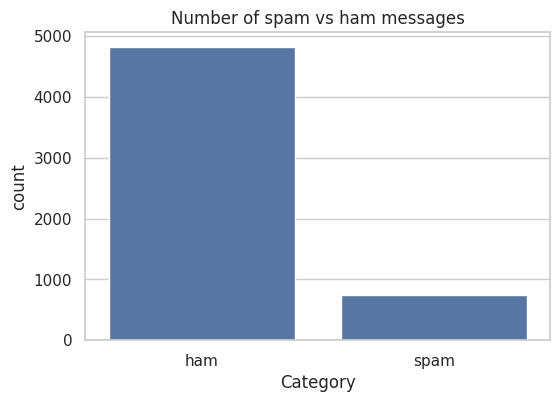

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Category")
plt.title("Number of spam vs ham messages")
plt.show()


Ham messages make up close to 88% of the dataset, with spam making up the rest. This is an imbalanced dataset. It means a lazy model that always predicts "ham" could still score a high accuracy without actually being useful.

## Step 4: Clean and preprocess the text

Raw text messages contain a lot of noise for a model: capital letters, punctuation, numbers, and common filler words like "the" or "and" that do not carry much meaning on their own. We clean all of this up before feeding the text into a model.

Our preprocessing pipeline does the following, in order:
1. Convert everything to lowercase
2. Remove punctuation
3. Split the message into individual words (tokenization)
4. Remove stopwords, common filler words that carry little meaning

In [8]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and word.isalpha()]
    return " ".join(tokens)

df["cleaned_message"] = df["Message"].apply(clean_text)

df[["Message", "cleaned_message"]].head()


,Message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts may...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


**Why each step matters:**
1. Lowercasing means "Free" and "free" are treated as the same word, instead of two different ones
2. Removing punctuation stops symbols like "!!!" from being treated as meaningful words
3. Tokenizing splits a sentence into a list of individual words, which is what lets us filter and count words
4. Removing stopwords keeps only the words that actually carry meaning, since "the," "is," and "and" appear constantly in both spam and ham and do not help tell them apart

## Step 5: Turn text into numbers using TF-IDF

Machine learning models need numbers, not raw words. TF-IDF, short for Term Frequency, Inverse Document Frequency, converts each message into a row of numbers, one number per word in our whole vocabulary.

Here is what TF-IDF actually measures for each word in a message:
1. Term Frequency, how often that word appears in this particular message
2. Inverse Document Frequency, how rare that word is across all messages in the dataset

A word gets a high TF-IDF score in a message if it appears often in that message but is rare across the rest of the dataset. This means TF-IDF naturally gives more weight to distinctive words, like "winner" or "prize," and less weight to common words that show up everywhere.

In [10]:
vectorizer = TfidfVectorizer(max_features=3000)

X = vectorizer.fit_transform(df["cleaned_message"])
y = df["Category"].map({"ham": 0, "spam": 1})

print("Shape of our TF-IDF matrix (messages, vocabulary size):", X.shape)


Shape of our TF-IDF matrix (messages, vocabulary size): (5572, 3000)


We limited the vocabulary to the 3000 most frequent words using `max_features=3000`. This keeps the model efficient and avoids giving weight to extremely rare words that appear only once or twice in the whole dataset and are unlikely to generalize well.

## Step 6: Split the data into training and testing sets

We use stratified splitting here, which makes sure the same proportion of spam and ham messages appears in both the training set and the testing set. This matters more than usual because our classes are imbalanced.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 4457
Testing samples: 1115


## Step 7: Train two classifiers

We train:
1. Multinomial Naive Bayes, the traditional, industry standard choice for text classification problems like this one
2. Logistic Regression, a strong general purpose classifier, for comparison

In [12]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)


In [13]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

log_reg_preds = log_reg.predict(X_test)


## Step 8: Evaluate both models

We look at four measures for each model:
1. Accuracy, percentage of messages classified correctly overall
2. Precision, of the messages the model flagged as spam, what percentage actually were spam
3. Recall, of all the actual spam messages, what percentage did the model successfully catch
4. F1 score, a single number that balances precision and recall together

We also look at a confusion matrix for each model, which breaks down exactly which messages were correctly or incorrectly classified.

In [14]:
def evaluate(name, y_true, y_pred):
    print(f"{name}")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"  Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"  F1 score:  {f1_score(y_true, y_pred):.3f}")
    print()
    print("Confusion matrix (rows are actual, columns are predicted):")
    print(confusion_matrix(y_true, y_pred))
    print()
    print("Full classification report:")
    print(classification_report(y_true, y_pred, target_names=["ham", "spam"]))
    print("-" * 60)

evaluate("Multinomial Naive Bayes", y_test, nb_preds)
evaluate("Logistic Regression", y_test, log_reg_preds)


Multinomial Naive Bayes
  Accuracy:  0.971
  Precision: 0.992
  Recall:    0.792
  F1 score:  0.881

Confusion matrix (rows are actual, columns are predicted):
[[965   1]
 [ 31 118]]

Full classification report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115

------------------------------------------------------------
Logistic Regression
  Accuracy:  0.961
  Precision: 1.000
  Recall:    0.711
  F1 score:  0.831

Confusion matrix (rows are actual, columns are predicted):
[[966   0]
 [ 43 106]]

Full classification report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.71      0.83       149

    accuracy                

### Visual confusion matrices

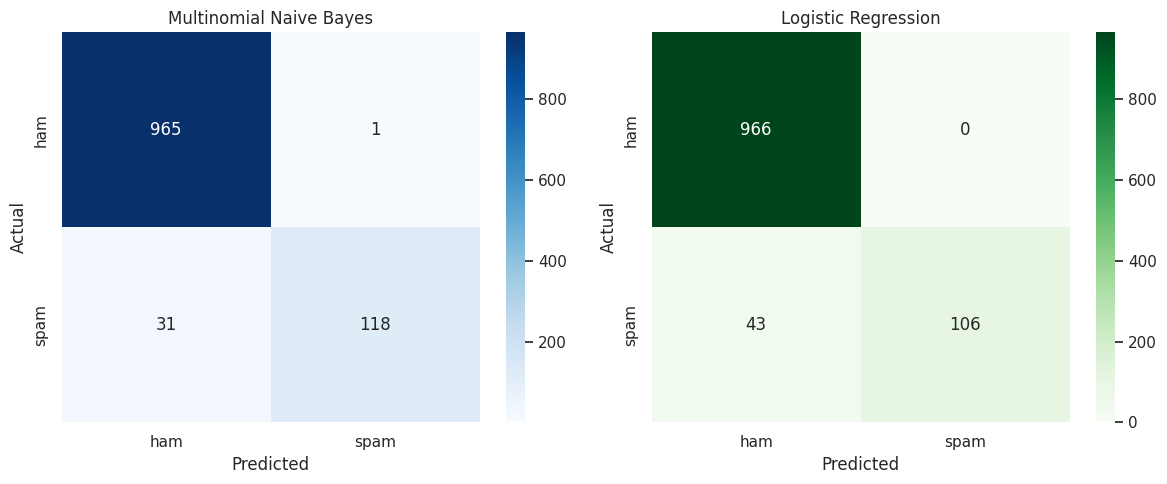

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_nb = confusion_matrix(y_test, nb_preds)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"], ax=axes[0])
axes[0].set_title("Multinomial Naive Bayes")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_lr = confusion_matrix(y_test, log_reg_preds)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"], ax=axes[1])
axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


## Step 9: Why is recall particularly important for spam detection?

In spam detection, the two kinds of mistakes a model can make are not equally bad:

1. **False negative**, a spam message that the model wrongly lets through as ham. This means the user still sees the spam message in their inbox, which is annoying and sometimes dangerous, for example a phishing message they might click on
2. **False positive**, a real, legitimate message that the model wrongly flags as spam. This means the user might miss an important message entirely, because it got hidden in a spam folder they rarely check

Recall specifically measures how many of the actual spam messages the model successfully caught. A low recall means many spam messages are slipping through undetected as false negatives, which is often the more dangerous mistake, since a missed spam or phishing message can lead to real harm, while a legitimate message wrongly marked as spam is usually just an inconvenience that can be corrected by checking the spam folder.

This means that when tuning a spam filter, we often care more about maximizing recall on the spam class than about squeezing out a slightly higher overall accuracy number, especially in contexts like phishing detection where missing a dangerous message has a real cost.

## Step 10: Bonus, word clouds for spam and ham

A word cloud is a visual where words that appear more often are shown bigger. This is a quick way to see which words are most associated with spam versus ham messages.

This step needs one extra library, `wordcloud`, which is not installed in Colab by default. The cell below installs it.

In [16]:
!pip install wordcloud --quiet


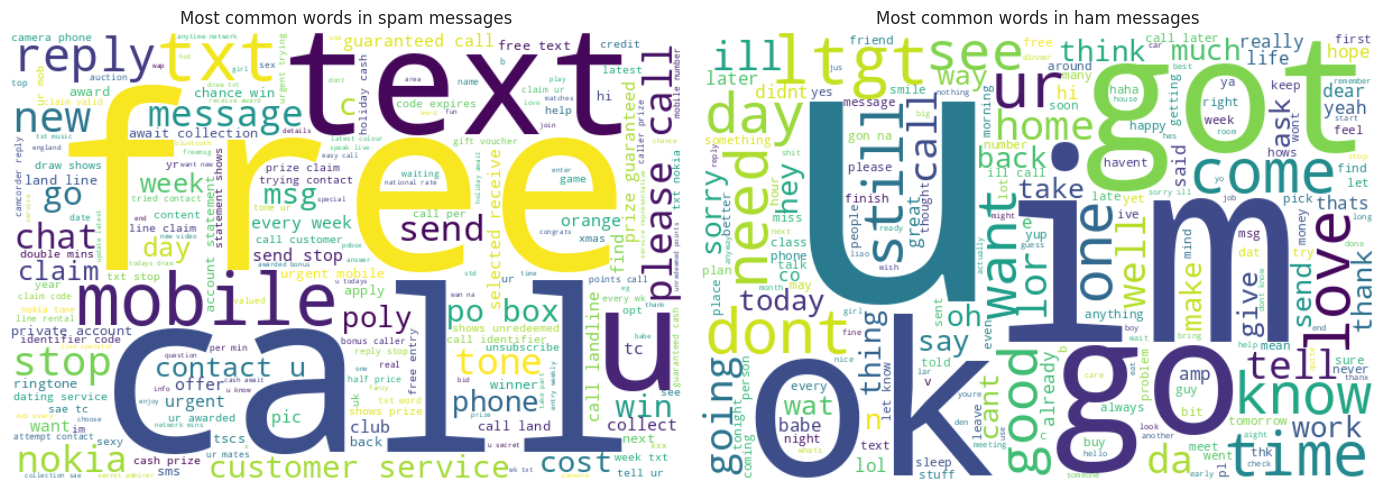

In [19]:
from wordcloud import WordCloud

spam_text = " ".join(df[df["Category"] == "spam"]["cleaned_message"])
ham_text = " ".join(df[df["Category"] == "ham"]["cleaned_message"])

spam_cloud = WordCloud(width=600, height=400, background_color="white").generate(spam_text)
ham_cloud = WordCloud(width=600, height=400, background_color="white").generate(ham_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(spam_cloud, interpolation="bilinear")
axes[0].set_title("Most common words in spam messages")
axes[0].axis("off")

axes[1].imshow(ham_cloud, interpolation="bilinear")
axes[1].set_title("Most common words in ham messages")
axes[1].axis("off")

plt.tight_layout()
plt.show()


The spam word cloud highlights words like "free," "mobile," "reply," "call," "text," and "claim," urgency language. The ham word cloud shows more everyday, conversational words like "get," "go," "time," "ok," and "u," reflecting normal personal messages.

## Conclusion



Both models performed strongly on this dataset, with Multinomial Naive Bayes achieving a slightly higher F1 score than Logistic Regression. Both models achieved high precision, meaning very few legitimate messages were wrongly flagged as spam, and reasonably high recall, meaning most spam messages were correctly caught. Given the importance of recall in spam detection, the model with the higher recall score would be the better fit for a real world spam filter, since missing spam is generally a more costly mistake than occasionally flagging a legitimate message. The word cloud visualizations confirm that spam messages rely heavily on urgency and reward language, while ham messages reflect ordinary day to day conversation.
